<a href="https://colab.research.google.com/github/nishant26baisoya-code/Data-science_gen_-ai_project/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Linear Regression Algorithm



**Task** : House Price Prediction









In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib. pyplot as plt
#Load the dataset and create a Dataframe
df=pd.read_excel("fetch_california_housing.xlsx")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422


As part of preprocessing,check for nulls and impute
with mean ,median or mode


In [66]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'price'],
      dtype='object')

In [67]:
#price--->o/p column
#remianing all the column are i/p column

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  int64  
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  int64  
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   price       20640 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 1.4 MB


checking for nulls

In [69]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
price,0


In [70]:
df.describe()  #computes aggregations for each column

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Finding the correlation:

Does any correlation exists b/w my independent and dependant variable

To check any correlation exists or not

Pandas provides a method called---->corr()

df.corr()--->It gives correlation for all your features

correlation values should be b/w -1 to +1

In [71]:
#Finding the correlation
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


-1 to 0---->Negative correlation

 0 t0 1---->Positive correlation

 0     ---->No Correlation


df.corr()---->give co-occurence matrix

              It gives correlation across all the features

observe the obove correlation

here MedianInc - MedianINC

     MedianINC- HouseAge

     MedianINC- AveRooms

              -AVeBedRooms
              
                 -
                 -
similarly Housage correlation with all the other i/p variables

similarly all i/p variables with all the other i/p variables

It gives correlation across all the features-->Co-occurence matrix

Make sure that none of the columns have 0 correlation

The last column giving correlation coefficient
b/w each i/p and target variable

The last column(price)-->gives how much it is
correlated with each i/p

<Axes: >

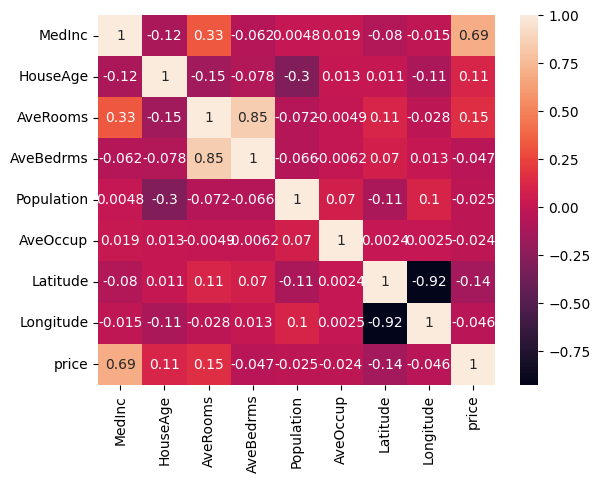

In [72]:
sns.heatmap(df.corr(),annot=True)

Here we use Seaborn to visualize the correlation matrix of a dataset as a heatmap

heatmap() displays data as a color-coded matrix

This is default seaborn Heatmap

annot=True

annot stands for annotations

when True,it prints the numeric correltion values inside each cell of the heatmap

This makes the plot easier to interpret


By default the correlation we are going is
Pearson Correlation, which measures the linear relationships

white color----->Perfect positive

light orange---->Strong positive  ex: 0.85

dark orange----->weak positive    ex: 0.30

red color------->weak negative   ex:-0.1

dark red-------->strong negative ex:-0.9

<Axes: >

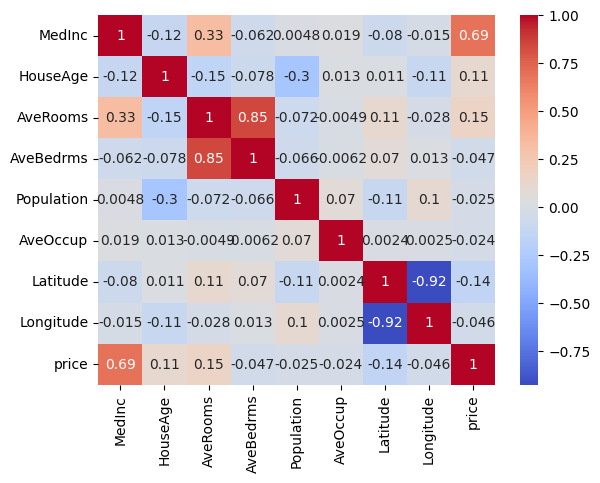

In [73]:
#Another type
sns.heatmap(df.corr(),cmap="coolwarm",annot=True)

**Multi-Collinearity issue(VIF)**
  -one i/p variable having high correlation with another i/p variable, we call this as
  Multi-collinearity issue

  here we have a methos called VIF

  (VIF-Variance Inflation Factor)

  -This VIF will identify whether there is a
   multi-collinearity issue exists across the
   i/p variables

   before doing this--->First we need to identify and divide the i/p features and target variable

   In df--->Except price, remaining all are the i/p features

   so to get the i/p features--->just drop the price column from the df.

In [74]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
X=df.drop(columns=['price']) #independent features
y=df['price']                #dependant feature

#or
X_input=df.iloc[:,:-1]        #indeendent features
y_output=df.iloc[:,-1] #dependent feature

In [75]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25,5.045455,1.133333,845,2.560606,39.48,-121.09
20636,2.5568,18,6.114035,1.315789,356,3.122807,39.49,-121.21
20637,1.7000,17,5.205543,1.120092,1007,2.325635,39.43,-121.22
20638,1.8672,18,5.329513,1.171920,741,2.123209,39.43,-121.32


In [76]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25


In [77]:
y.head()

,price
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [78]:
X_input.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25


In [79]:
y_output.head()

,price
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [149]:
print(X.shape[0])
print(X.shape[1])  #displays the no of columns

20640
6


In [81]:
#Create a empty dataframe to store results of VIF
vif_data=pd.DataFrame()  #vif_data is an empty df
#Now in this df, I want 2 columns--->1)Features
#                                    2)VIF value
vif_data["Features"]=X.columns
#vif_data
vif_data['VIF']=[variance_inflation_factor(X,i) for i in range(X.shape[1])]
vif_data

,Features,VIF
0,MedInc,11.511140
1,HouseAge,7.195917
2,AveRooms,45.993601
3,AveBedrms,43.590314
4,Population,2.935745
5,AveOccup,1.095243
6,Latitude,559.874071
7,Longitude,633.711654


To calculate VIF--->Comparing X(all features) with each i/p variable

vif(X,i) here comparing all features(X) with each i/p variable(i) for getting each i/p variable(i), am applying for loop

X.shape[1]--->8 columns , so for loop executes for 8times so it takes each i/p variable(i) one by one and campares

i--->passing one by one column

So for every independent variable,we calculated VIF value vif(X,i)-->i is each column compared with all other columns(X), here X has all columns

Here df has 2 columns-->1)Features and 2) VIF

if VIF < 5--->No Multcollinearity issue

if VIF > 5--->Multicollinearity issue

but here VIF values are too high---->559,633,45,43 ->abnormal

This is bcoz of diff scaling in each column so apply Standard scaler

X is not scaled, so apply standard scaler

Now performing scaling--->using Standard scalar

In [82]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

X_scaled

array([[ 2.34476576,  0.98214266,  0.62855945, ..., -0.04959654,
         1.05254828, -1.32783522],
       [ 2.33223796, -0.60701891,  0.32704136, ..., -0.09251223,
         1.04318455, -1.32284391],
       [ 1.7826994 ,  1.85618152,  1.15562047, ..., -0.02584253,
         1.03850269, -1.33282653],
       ...,
       [-1.14259331, -0.92485123, -0.09031802, ..., -0.0717345 ,
         1.77823747, -0.8237132 ],
       [-1.05458292, -0.84539315, -0.04021111, ..., -0.09122515,
         1.77823747, -0.87362627],
       [-0.78012947, -1.00430931, -0.07044252, ..., -0.04368215,
         1.75014627, -0.83369581]])

Now Re-execute to find VIF on X_Scaled data and check any changes in previous and this

In [83]:
#Here change X to X_scaled
#Create a empty dataframe to store results of VIF
vif_data=pd.DataFrame()  #vif_data is an empty df
#Now in this df, I want 2 columns--->1)Features
#                                    2)VIF value
vif_data["Features"]=X.columns
#vif_data
vif_data['VIF']=[variance_inflation_factor(X_scaled,i) for i in range(X_scaled.shape[1])]
vif_data

,Features,VIF
0,MedInc,2.501295
1,HouseAge,1.241254
2,AveRooms,8.342786
3,AveBedrms,6.994995
4,Population,1.138125
5,AveOccup,1.008324
6,Latitude,9.297624
7,Longitude,8.962263


If data is not scaled, whatever we perform is not accurate so bring into some scaling, now data is scaled(normalized)

IF VIF>5 --->means Multicollinerity issue, we have redundant columns

we observe --->Latitude and Longitude both have values above 5, means both are highly correlated so these are redundant columns

remove any one column---->which column to remove--->?

check among these 2 columns--->which has high correlation, then keep that column and remove the other column

As longitude is high correlated with target -->select it

similarly, AveRooms and AveBedrms have VIF >5, so these are also highly correlated-->redundant

Remove any one--->As AVeRooms has high correlation with target--->so Remove AveBedrms

In [84]:
#Now select the remaining features excluding the above 2 redundant columns
X=X[['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup','Longitude']]

#Now i will apply scaling for this X--->which has less columns as before
X_scaled=scaler.fit_transform(X)
X_scaled

array([[ 2.34476576,  0.98214266,  0.62855945, -0.9744286 , -0.04959654,
        -1.32783522],
       [ 2.33223796, -0.60701891,  0.32704136,  0.86143887, -0.09251223,
        -1.32284391],
       [ 1.7826994 ,  1.85618152,  1.15562047, -0.82077735, -0.02584253,
        -1.33282653],
       ...,
       [-1.14259331, -0.92485123, -0.09031802, -0.3695372 , -0.0717345 ,
        -0.8237132 ],
       [-1.05458292, -0.84539315, -0.04021111, -0.60442933, -0.09122515,
        -0.87362627],
       [-0.78012947, -1.00430931, -0.07044252, -0.03397701, -0.04368215,
        -0.83369581]])

In [85]:
#The above features doesnt have multi-collinearity issue
#This is part of pre-processing

Next is Dividing the data into Trainset and Testset

Before we apply the model-->we need to divide our data into

1)trainset

2)testset

for this we go for sklearn

In [86]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=1)

#X_scaled--->i/p
#y--->target
#test_size=0.2(20%)
#random_state=1 --->whenever we split,we need to maintain any pointer for splitting
#                  If pointer is maintained, for every run we get the same split using the same pinter
#                  from that random state it starts splitting
#same no of records will be splitted b/w train and test

#The split gives diff o/ps---->X_train,X_test,y_train,y_test

In [87]:
X_train.shape    #returns the no of rows and cols (we see 80% data--->used to train the model)

(16512, 6)

In [88]:
X_test.shape   #we see 20% data---->unseen data (not used for training the model)

(4128, 6)

In [89]:
#What is random state ----->Controls the shuffling and splitting of data
#provide any value to random state-->then it guarantees the same train set and test test for every run
#or execution
#Advantage: It is importatant for consistent model evaluation and debugging process

#If no random state provided--->for every execution or for every run--->
# we get different trainset and test set

In [150]:
#sample example on Random state
from sklearn.model_selection import train_test_split
import numpy as np

X1=np.arange(10).reshape(5,2)
y1=range(5)
print(X1)
print(y1)

#split with  a fixed random state(same split every time)
X1_train,X1_test,y1_train,y1_test=train_test_split(X1,y1,test_size=0.2,random_state=1)

print(X1_train)
print(X1_test)

[[0 1]
 [2 3]
 [4 5]
 [6 7]
 [8 9]]
range(0, 5)
[[2 3]
 [8 9]
 [0 1]
 [6 7]]
[[4 5]]


In [151]:
#split without a random state(diff split everytime)
X1_train2,X1_test2,y1_train2,y1_test2=train_test_split(X1,y1,test_size=0.2)
print(X1_train2)
print("\n")
print(X1_test2)

[[6 7]
 [0 1]
 [4 5]
 [2 3]]


[[8 9]]


In [152]:
"""
#Dividing data into train and Testset

data---->80%--->train data----->X_train(80%),Y_train(80%)
                                X_test(20%),Y_test(20%)

    <X_train>   <y_train>
    age exp      sal
     -   -        -
     .             --------->80%                    ------->!00% data
     .
------------------------------------
  <X_test>     <y_test>
  age exp      sal  ------->20%
     -   -        -

next

train data --------------->model------>Evaluating on------->testdata------->predicts
(X_train,y_train)                                           (X_Test)        (Y_pred)


actual    -  predicted   =Error
(y_test)     (y_pred)
  24            20       =4
"""

'\n#Dividing data into train and Testset\n\ndata---->80%--->train data----->X_train(80%),Y_train(80%)\n                                X_test(20%),Y_test(20%)\n\n    <X_train>   <y_train>\n    age exp      sal\n     -   -        -\n     .             --------->80%                    ------->!00% data\n     .\n------------------------------------\n  <X_test>     <y_test>\n  age exp      sal  ------->20%\n     -   -        -\n\nnext\n\ntrain data --------------->model------>Evaluating on------->testdata------->predicts\n(X_train,y_train)                                           (X_Test)        (Y_pred)\n\n\nactual    -  predicted   =Error\n(y_test)     (y_pred)\n  24            20       =4\n'

Importing Linear Regression model

For Every SKlearn Algorithm-->we see 3 steps

1)initilaize the model

2)training the model with trainset i.e X_trainand y_train

3)Predicting on the newsataset

In [124]:
from sklearn.linear_model import LinearRegression

#1.Initilaizing the model
model=LinearRegression()

In [125]:
#2.Training the model usind X_train and y_train
model.fit(X_train,y_train)

LinearRegression()

Now my model is trained

Once model is trained

How will we check that model learned

i.e using coefficients--->slope and intercept

In [126]:
#Getting the optimal intercept
model.intercept_

np.float64(2.0758670919351676)

In [127]:
#Getting the optimal coeffiecients
model.coef_

array([ 0.84557223,  0.22625074, -0.05470288,  0.03534907, -0.04534919,
       -0.02430719])

In [128]:
#Here for every i/p feature---->we got the coefficients
#Now predicting on (X_test)data
y_pred=model.predict(X_test)
y_pred

array([1.98742938, 1.38942055, 2.50725776, ..., 2.5491381 , 2.72856198,
       1.92824489])

In [129]:
y_test

,price
4712,3.550
2151,0.707
15927,2.294
82,1.125
8161,2.254
...,...
2319,0.682
5341,2.250
16888,3.500
6823,2.273


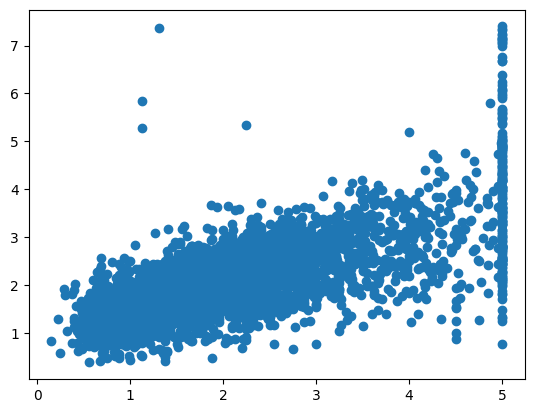

In [130]:
y_test #Actual value
y_pred #predicted value
#using matplotlib---->a scatter plot
plt.scatter(y_test,y_pred)


In [131]:
#Now we see the model predicted values
#Upto now we have seen how the algorithm is operating or functioning
#we no need to do manually-->we got pre-built model ---->LinearRegresssion()
#which takes care of all the implementation
#Now we got the optimal intercept and slope values

#Next is Regularization tEchniques
#we have some metrice
#1)MAE
#2)MSE
#3)RMSE
#4)R-square

#Next is checking whether the model is predicting well or not

Overview

-we checked Correlation

-we checked for multi-collinearity

-we performed Scaling

-WE splitted data into train set and test set

-we trained model using trainset

-initilizing Linear Regrression

-training the model using X_train and y_train

-predicting

-Next is Evaluating the model (How good the model is predicting)

Evaluating Regression Models

List of Evaluation metrics 1)MEAN ABSOLUTE ERROR(MAE)

2)MEAN SQUARE ERROR(MSE)

3)ROOT MEAN SQUARE ERROR(RMSE)

4)R-SQUARE

For REgression,we have seperate set of performance/evaluation metrics

Similarly for classification,we have seperate set of performance/Evaluation metrics

Its nor necessary to remember the formula

we use this metrics in calculating the error and predicting the accuracy

X_test(unseen)------->Model--->y_pred

Compare y_pred and y_test(actual)

Now check how much error and how much accuracy

For Calculating accuracy--->we use R-Square

For Error Calculating---->MAE,MSE,RMSE

For Accuracy calculation------>R-Square

For Accuracy calculation------>R-Square

y_actual =40 LAkhs

y_pred =42 lakhs

Error=y_pred -y_actual =42 -40 =2 is the error
----------------------------------------------
MEAN SQUARED ERROR (MSE)

                       2

MSE =(y_pred - yactual) /n


 n is no of observations


R-Square =80%

means model accurcy is 80%

For R-Square - Coefficient of determinant

means how much your predicted value is far
from Original value

i.e how close it is with mean

----------------------------------------------                      
R-Square=(ypred - y^)2/(y-y^)2

y^--->mean

y---->actual value

ypred->predicted value

----------------------------------------------
MEAN ABSOLUTE ERROR(MAE)
   -diff b/w model prediction and actual value


MAE=sum|(xi-x)|/n

xi--->Actual value
x---->predicted value

n- No of observations
----------------------------------------------
ROOT MEAN SQUARED ERROR(RMSE)

sqrt(MSE)



**R-Square(Accuracy)**

-how close the data to predicted Regression line

It is also called as coefficient of determination


R-Square =sum(predicted Distance -mean)2/sum(Actual distance-Mean)2

i.e sum(yp -y^)2/sum(y-y^)2

In [105]:
y_pred

array([1.98742938, 1.38942055, 2.50725776, ..., 2.5491381 , 2.72856198,
       1.92824489])

In [132]:
y_test

,price
4712,3.550
2151,0.707
15927,2.294
82,1.125
8161,2.254
...,...
2319,0.682
5341,2.250
16888,3.500
6823,2.273


In [133]:
#Evaluation Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
#To calculate error---->we require y_pred and y_test
print("MEAN ABSOLUTE ERROR:========>",mean_absolute_error(y_test,y_pred))
print("MEAN Squared ERROR:========>",mean_squared_error(y_test,y_pred))
print("RMSE:========",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2_Score:========>",r2_score(y_test,y_pred))

MEAN ABSOLUTE ERROR:========> 0.5978652478722021
MEAN Squared ERROR:========> 0.6446618454056534
RMSE:======== 0.8029083667552939
R2_Score:========> 0.508526076422758


based on R2_score

Here only 50% accuracy

This model is not fit for this data

Is there any other model which gives high a

Next exploring diff algorithms which gives more accuracy

we should compare multiple models accuracy and select any one

using R2_score only,we can check which model gives good accuracy

IN Datascience,everytime we need to explore with multiple models and select the best

Always errors should be less

R_score should be more

RSS And R2_score both are differenet
For the best performance-->error =0

for the best performance-->accuracy=100

**Bias and Variance**
For any Datascience Best-fit model, we should have low bias and low variance

This will help to check whether ur model is overfitted or not

**what is Bias??**

For any Datascience model, we are doing train and test split

**traindataset(R2_score)**

-when we pick this, we are checking the accuracy of traindataset and also accuracy of testdataset

we do R2_score for both train and test dataset

assume ur trained dataset accuracy=60%

test dataset accuracy =58%

According to datascience best practices,when we explore any mode,you should reach min 80% of accuracy--->considerably good

if <80% --->then ur model is underfitted model

Your model is not good(or)

Your dataset is not good

here actually ur train accuracy itself is less
forget about test accuracy

We call this kind of situation as high bias(when trainset accuracy is less)
and also we say it as underfit model

means soo much of error in models

means 60% of accuracy and 40% of errors

i.e high bias--->high error

This is called underfit model

**what is Variance?**
Difference b/w the train accuracy to test accuracy

Variance means the deviation b/w the train and test accuracy

i.e trainaccuracy - test accuracy
             60%   - 58%  =2%

if the difference is below 5% i.e the deviation b/w the train and test accuracy if it is less than 5% then we call it as low variance

ex:

Train accuracy---->98% (is good-->low bias)

Test accuracy----->70%

             ------------

                   28%  > 5% ->high variance

This kind of analogy is called overfitted model

means for trainset---->good accuracy

      for testset----->less accuracy
      

In [134]:
#  Model              Bias(Error)        Variance(Deviation b/w Trainset and Testset accuracy)
#1.Best-Fit model       Low                 Low
#2.Under-Fit model      High                Low
#3.Over-Fit model       Low                 High

#=========================================================================================
#ex: Best-Fit model----->Trainset =98%(low bias,less error)
#                        Testset  =96%
#                                 ------
#                                   2%  < 5% --->low variance
#ex: student doing excellent in both train(class) and test(exam)
#=========================================================================================
#ex: Under-Fit model----->Trainset =60%(High bias,High error)
#                         Testset  =58%
#                                 ------
#                                   2%  < 5% --->low variance
#ex: student doing bad in both train(class) and test(exam)
# Under-fit is like low confidence in responding in both class and exam
#========================================================================================
#ex: Over-Fit model----->Trainset =98%(Low bias,Low error)
#                        Testset  =70%
#                                 ------
#                                   28%  > 5% --->High variance
#ex: student doing good in  train(class) and bad in test(exam)
# overfit is like over confidence(Good in class but bad in exams)

So you need to know

whether your model is----->Over-fitted

whether your model is----->under-fitted

whether your model is----->Best-Fitted


**Overfitting:**

Ex: Students studying for exam

One student is understanding the concept,logic and studies

another student(Student2)-->he is just memorizing

Both of the students going for exam

Now in the exam
  -If some question asked from the texbook then both of the students writes well,especially student2 writes well.

But in otherside
another question--->asked in a different manner but the logic is same(concept is same),but in different way it was asked

student1 will write well as he knows the concept and logic in it.

But student2 gets the lowest score

similar to that our ML model also,
it extracts the patterns and behavior from the data

ex: To predict the salary of a employee,
    yrs of exp and age is enough to predict the salary

 -Now the model is learning the logic and patterns based on yrs of exp and age-->learning patterns from these and predicting

 as long as it learns the patterns, its good

 but if i add some additional/extra features then the model gets added information that is our assumption

 But actually yrs of exp and age is enough to predict the slary

 but if we keep on adding diff other features such as address,location of emp , model keeps learning the patterns,it keeps on
 understanding the correlation among the independant and dependant variables and based on that it will understand and learn the patterns

 but if you pass only neccessary features then the model do very well

 but once you start passing many unwanted features then ur algorithm will learn those
 patterns also

 again you keep on adding new features -then model keep on learning patterns,at one point it wont be able to understand the core correlation and it wont understand the logic and patterns--->then it will start memorizing
 it will lead to overfit

 here with traindatset--->it gives high accuracy---->98%

 with testdata--->It gives less accuracy-->40%

 This kind of behavior in most of the cases in datascience we call it as overfitting

means--->low bias and high variance

we have lot of techniques to avoid overfitting

1)Mult--collinearity:
   
  -If you find this issue,using VIF (or) using correlation (or) correlation matrix,we can remove unwanted columns which avoids overfitting

we have Regularization techniques to overcome overfitting such as

2)Lasso Regression Algorithm

3)Ridge Regression Algorithm

4)Elastic-Net Algorithm

LASSO Regression

LASSO - Least Absolute selection shrinkage operator

The above 3 algorithms comes with Penalization technique,

Penalization technique means identifying the features which doesnt have high-correlation with the target

ex:address doesnt have high correlation with the target-salary

Lasso Regression-->takes ur Residual sum sqaure error(RSS) +sum of lambda(T) times of beta(B) coefficients

i.e RSS +sum(lambda .|B|)

Here Beta(B) is the coefficients, we take absolute values of coefficients

Here lambda(T) is the shrinkage parameter (or) learning parameter (or) Hyper-parameter

It is going to penalize ur unwanted features

Ridge **Regression**

-Here instead of absolute value of coefficients it takes
               
RSS+sum(lambda.Bsquare)

Here instead of absolute values of coefficients

Here we are squaring the coefficients

Diff b/w Lasso and Ridge is

LAsso is absolute value of coefficients |B|

Ridge is taking square value of coefficients(B)-square

**Elastic-Net**

-It simply combines Lasso + Ridge

Concept wise--->Lasso,Ridge and Elastic-Net comes under Regulaization techniques

when to go for these--->??

-to avoid over-fitting

Each one is a Regaulization technique

here which is the best??? --->all

-we need to explore and find the best ome

-Datascience is a kind of research subject

-people should keep on researching

which one is the best

Each one is best for certain types of datasets

-we wont know for which kind of datasets, we need to explore

-These are simple to implement, no need to remember the formulas

In [135]:
#Implementing Regression Algorithm
from sklearn.linear_model import Lasso,Ridge,ElasticNet

#For any model-->4steps
#i) initialize the model
#ii) fit the model---> train model
#iii) predict /test the model
#iv) Evaluating the model

#i) initializing the model
lesso_model=Lasso()

#ii) fit (or) train the model
lesso_model.fit(X_train,y_train) #as it is supervised--->we need to pass both(X_train and y_train)

Lasso()

In [136]:
lesso_model.intercept_

np.float64(2.077350641957364)

In [137]:
lesso_model.coef_

array([ 0.,  0.,  0., -0., -0., -0.])

In [138]:
#iii) predict the model with Test Data
lesso_y_pred=lesso_model.predict(X_test) #lasso predciting on testdata
lesso_y_pred


array([2.07735064, 2.07735064, 2.07735064, ..., 2.07735064, 2.07735064,
       2.07735064])

In [139]:
#iv) Evaluating the model
#(copy the previous code and just change y_pred to lasso_y-pred)

#Evalutaion Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
#To calculate error---->we require  y_pred and y_test
print("MEAN ABSOLUTE ERROR:========>",mean_absolute_error(y_test,lesso_y_pred))
print("MEAN Squared ERROR:========>",mean_squared_error(y_test,lesso_y_pred))
print("RMSE:========>",np.sqrt(mean_squared_error(y_test,lesso_y_pred)))
print("R2_Score:========>",r2_score(y_test,lesso_y_pred))


MEAN ABSOLUTE ERROR:========> 0.9090896299308748
MEAN Squared ERROR:========> 1.3136235330402446
RMSE:========> 1.1461341688651658
R2_Score:========> -0.0014734336890012134


R2_score is too much penalized,getting lowest percent in negative

-This is a underfit model

-Even if you see the Error--->0.90

-So Lasso is not doing good

****Ridge Regression****

In [140]:
#Expressing with Ridge Regression(Copy the same code of above)
#i) initialize the model
ridge_model=Ridge()

#ii) fit (or) train the model
ridge_model.fit(X_train,y_train)

#iii) predict the model with Test data
ridge_y_pred=ridge_model.predict(X_test) #lesso predicting on testdata
ridge_y_pred

#iv)Evaluation Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
#To calculate error---->we require y_pred and y_test
print("MEAN ABSOLUTE ERROR:========>",mean_absolute_error(y_test,ridge_y_pred))
print("MEAN Squared ERROR:========>",mean_squared_error(y_test,ridge_y_pred))
print("RMSE:========>",np.sqrt(mean_squared_error(y_test,ridge_y_pred)))
print("R2_score:========>",r2_score(y_test,ridge_y_pred))



MEAN ABSOLUTE ERROR:========> 0.5978688280402985
MEAN Squared ERROR:========> 0.6446591827377683
RMSE:========> 0.8029067086142501
R2_score:========> 0.508528106373564


Ridge is doing similar to linear Regression with 50% accuracy, so next explore with Elastic-Net

 **Elastic Net Regression**


In [141]:
#Exploring with Elastic-Net Regression(Copy the same code of above)
#i) initialize the model
elastic_net_model=ElasticNet()

#ii) fit (or) train the model
elastic_net_model.fit(X_train,y_train)

#iii) predict the model with Test Data
elastic_net_y_pred=elastic_net_model.predict(X_test) #lasso predciting on testdata

#iv)Evaluation Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
#To calculate error---->we require y_pred and y_test
print("MEAN ABSOLUTE ERROR:========>",mean_absolute_error(y_test,elastic_net_y_pred))
print("MEAN Squared ERROR:========>",mean_squared_error(y_test,elastic_net_y_pred))
print("RMSE:========>",np.sqrt(mean_squared_error(y_test,elastic_net_y_pred)))
print("R2_Score:========>",r2_score(y_test,elastic_net_y_pred))


MEAN ABSOLUTE ERROR:========> 0.8093321592027964
MEAN Squared ERROR:========> 1.0392295233784496
RMSE:========> 1.0194260754848532
R2_Score:========> 0.20771763523445108


It is also not doing well, we need to still explore

only for Linear regression and Ridge Regression we got 50% accuracy

So--->High Bias--->Underfit models

so for

Underfit models--->
1)Try adding new patterns of data


We are trying to learn the linear relationship b/w the independent to dependant variables

suppose if your data contains lot of non-Linearity then whatever we have explored like Linear,Lasso,Ridge,Elastic-Net, they may not fix

Your problem is non-Linearity i.e scattered

**For Non-Linearity,we have algorithms such as**

> Add blockquote

1.Decision-Tree Regression

2.Random Forest Regression

3.Support Vector Machines Regression

4.Gradient Boosting Regression

So for non-Linear these Linear,Lasso,Ridge,Elastic-Net wont work

**Decision Tree Regression**

Decision Tree is a Tree structure, where each internal node represents a test,each brach represents the outcome of a test,

Decision Tree is learning the dataset by traversing from a tree

It will plot your dataset as a tree-format

ex: Check the diagram

**Advantages of Decision Trees**

1)They are very eady to understand

2)with decision trees,data becomes simpler and easier



In [142]:
#Random Forest Regression:

#-Here data is divided into samples

#-These samples are given to decision trees

"""          samplesets          D.Trees
Data---------->S1  -------------->D.Tree1
    ---------->s2  -------------->D.Tree2
    ---------->s3  -------------->D.Tree3
    ---------->s4  -------------->D.Tree4
    ---------->s5  -------------->D.Tree5

RandomForest combines multiple decision trees to produce more powerfull results

RandomForest train each tree independently using random sample set

Here multiple trees can can be trained in parallel


Random Forest--->collection of trees
             --->through which it is trying to learn

here instead of taking decision from a single model--->we are taking decision from
multiple models--->this we call it as Ensemble--->i.e collection of multiple models

in Datascience,Every Algorithm learns in diferent ways

we will never know which algorithm does well for your dataset untill you explore with
different models
"""

'          samplesets          D.Trees\nData---------->S1  -------------->D.Tree1\n    ---------->s2  -------------->D.Tree2\n    ---------->s3  -------------->D.Tree3\n    ---------->s4  -------------->D.Tree4\n    ---------->s5  -------------->D.Tree5\n\nRandomForest combines multiple decision trees to produce more powerfull results\n\nRandomForest train each tree independently using random sample set\n\nHere multiple trees can can be trained in parallel\n\n\nRandom Forest--->collection of trees\n             --->through which it is trying to learn\n\nhere instead of taking decision from a single model--->we are taking decision from\nmultiple models--->this we call it as Ensemble--->i.e collection of multiple models\n\nin Datascience,Every Algorithm learns in diferent ways\n\nwe will never know which algorithm does well for your dataset untill you explore with\ndifferent models\n'

In [143]:
"""
Support Vector MAchine(SVM) Regressor:
    -It is a method for classification of both linear and non-linear data

    |        x
    |      x
    |    x          ------->Linear ----->Learning data from this
    |  x
    |_ _ _ _ _ _ _ _ _

     |
    |
    |    x    X      ------->non-Linear(curve or wave)----->Learning data from this
    |  x   X    X
    |_ _ _ _ _ _ _ _ _

           o  ---------------------->data points
          o    x-------------------->
    |    o    x  x------------------> Hyperplanes --->which seperate the datapoints
    |  o    x  x  o                               --->helping to seperate the datapoints
    | o   x  x  o
    |  x  x    o-------------------->data points
    |_ _ _ _ _ _ _ _ _

      No datapoints exists within the hyperplane

      The power of SVM is---->it is capable to handling linear data and non-Linear data
  """

'\nSupport Vector MAchine(SVM) Regressor:\n    -It is a method for classification of both linear and non-linear data\n\n    |        x\n    |      x\n    |    x          ------->Linear ----->Learning data from this\n    |  x\n    |_ _ _ _ _ _ _ _ _\n\n     |\n    |\n    |    x    X      ------->non-Linear(curve or wave)----->Learning data from this\n    |  x   X    X\n    |_ _ _ _ _ _ _ _ _\n\n           o  ---------------------->data points\n          o    x-------------------->\n    |    o    x  x------------------> Hyperplanes --->which seperate the datapoints\n    |  o    x  x  o                               --->helping to seperate the datapoints\n    | o   x  x  o\n    |  x  x    o-------------------->data points\n    |_ _ _ _ _ _ _ _ _\n\n      No datapoints exists within the hyperplane\n\n      The power of SVM is---->it is capable to handling linear data and non-Linear data\n  '

In [144]:
#Gradient Boosting:
"""
  -It is a kind of derivative Based

   Gradient Descent------>here gradient is decreasing

   why Gradient is decreasing???

   here it calculates the cost

   here cost means--->Error---->loss

  Error = loss = cost

  RSS =ypred - yact

  here Gradient descent means------>

  it takes your error and it keeps on learning based on multiple iterations

  It takes data and learns from the below curve

   Error
    |   X           X---->suppose you are here--->1st iteration (i,e slope)
    |    X         X      in order to reduce the error-->it calculates the gradient
    |      X      X       Gradient is calculated by partial derivative--> (d loss/d m) (d loss/d c)
    |        X X X----------->local minima (lowest error and lowest loss)
    |_ _ _ _ _ _ _ _ _

                                                      c--->intercept
                                                      m--->slope
                            These parameter m,c, we keep on adjusting in order to reduce
                            the error untill it reaches local minima(lowest error)

  According to Linear Regression---->y=mx+C

  we need to adjust this m and c--->what is the best value of m and c

  the rate of change of loss w.r.to 'm' and the rate of chnage of loss w.r.to 'c'

    i.e(d loss/d m)  (d loss/d c) --->m,c --->these 2 parameter values will be adjusted
    throught the gradient(partial derivative)

  it keeps on adjusting untill we reach the local minima

  multiple times it keeps on executing your model untill it reaches the local minima


so Gradient descent it is using partial derivative through which it is calculating the
Gradient
Gradient is the rate of change of value, how much rate of change needed so that
it reaches local minima

Gradient descent is one of the optimization technique -->it is trying to reduce the
 error/loss (ypred-yactual) to get the optimal m and c

All these algorithms(Decision Tree,Random Forest,SVM,Gradient descent) are helping
in understanding the non-linearity of data

Summary:
-------
Decision Tree----> how it is helping
It takes data and immediately plots tree-structure, through which it is going to learn

DT is one single Tree

Random Forest is collection of trees
instead of learning from one single tree model,it is building multiple decision tree models
and it is learning from collection of models

so collection of models gets good results, as compared with single model

in general we say--->Random Forest gives good accuracy aa compared with other

but for some specific datasets,Decision tress does well as compared with Random Forest


SVM Regressor---> It is creating a hyper plane
                  hyperplane can be a linear plane or curve-shaped plane with
                  that it is going to learn from non-linear data

Gradient Descent ---> optimization technique-->which uses partial derivative
                      through which it reduces the loss(error) and it is a
                      multiple iterative approach,
                      on each iteration it calculates the rate of change of paramter
                      values for 'm' and 'c' and it continues
                      it continues untill it reaches local minima

                      -our target is---->moving to local minima

                      -It is trying to reduce the error(loss)

"""

"\n  -It is a kind of derivative Based\n\n   Gradient Descent------>here gradient is decreasing\n\n   why Gradient is decreasing???\n\n   here it calculates the cost\n\n   here cost means--->Error---->loss\n\n  Error = loss = cost\n\n  RSS =ypred - yact\n\n  here Gradient descent means------>\n\n  it takes your error and it keeps on learning based on multiple iterations\n\n  It takes data and learns from the below curve\n\n   Error\n    |   X           X---->suppose you are here--->1st iteration (i,e slope)\n    |    X         X      in order to reduce the error-->it calculates the gradient\n    |      X      X       Gradient is calculated by partial derivative--> (d loss/d m) (d loss/d c)\n    |        X X X----------->local minima (lowest error and lowest loss)\n    |_ _ _ _ _ _ _ _ _\n\n                                                      c--->intercept\n                                                      m--->slope\n                            These parameter m,c, we keep on adj

**Decision Tree Regressor Algorithm**

In [145]:
from sklearn.tree import DecisionTreeRegressor

#1. Initialize the Model
dt_model=DecisionTreeRegressor()

#2. Fit or Train the Model
dt_model.fit(X_train,y_train)

#3.Predict the Model with Test Data
dt_y_pred=dt_model.predict(X_test)

#4.Evaluate the Model
print("MEAN ABSOLUTE ERROR:========>",mean_absolute_error(y_test,dt_y_pred))
print("MEAN Squared ERROR:========>",mean_squared_error(y_test,dt_y_pred))
print("RMSE:========>",np.sqrt(mean_squared_error(y_test,dt_y_pred)))
print("R2_Score:========>",r2_score(y_test,dt_y_pred))

MEAN ABSOLUTE ERROR:========> 0.5496055813953489
MEAN Squared ERROR:========> 0.6929712083135658
RMSE:========> 0.8324489223451286
R2_Score:========> 0.4716962371774581


**Random Forest Regressor Algorithm**




In [146]:
from sklearn.ensemble import RandomForestRegressor

#1. Initialize the Model
rf_model=RandomForestRegressor()

#2. Fit or Train the Model
rf_model.fit(X_train,y_train)

#3.Predict the Model with Test Data
rf_y_pred=rf_model.predict(X_test)

#4.Evaluate the Model
print("MEAN ABSOLUTE ERROR:========>",mean_absolute_error(y_test,rf_y_pred))
print("MEAN Squared ERROR:========>",mean_squared_error(y_test,rf_y_pred))
print("RMSE:========>",np.sqrt(mean_squared_error(y_test,rf_y_pred)))
print("R2_Score:========>",r2_score(y_test,rf_y_pred))

MEAN ABSOLUTE ERROR:========> 0.3958928412548452
MEAN Squared ERROR:========> 0.3395309798411156
RMSE:========> 0.582692869221098
R2_Score:========> 0.7411501486744028


**Support Vector MAchine Regressor Algorithm**

In [147]:
from sklearn.svm import SVR

#1. Initialize the Model
svr_model=SVR()

#2. Fit or Train the Model
svr_model.fit(X_train,y_train)

#3.Predict the Model with Test Data
svr_y_pred=svr_model.predict(X_test)

#4.Evaluate the Model
print("MEAN ABSOLUTE ERROR:========>",mean_absolute_error(y_test,svr_y_pred))
print("MEAN Squared ERROR:========>",mean_squared_error(y_test,svr_y_pred))
print("RMSE:========>",np.sqrt(mean_squared_error(y_test,svr_y_pred)))
print("R2_Score:========>",r2_score(y_test,svr_y_pred))

MEAN ABSOLUTE ERROR:========> 0.4576396040860188
MEAN Squared ERROR:========> 0.4460175097109757
RMSE:========> 0.6678454235157831
R2_Score:========> 0.6599675053766079


**Gradient Boosting Regressor Algorithm**

In [148]:
from sklearn.ensemble import GradientBoostingRegressor

#1. Initialize the Model
gbr_model=GradientBoostingRegressor()

#2. Fit or Train the Model
gbr_model.fit(X_train,y_train)

#3.Predict the Model with Test Data
gbr_y_pred=gbr_model.predict(X_test)

#4.Evaluate the Model
print("MEAN ABSOLUTE ERROR:========>",mean_absolute_error(y_test,gbr_y_pred))
print("MEAN Squared ERROR:========>",mean_squared_error(y_test,gbr_y_pred))
print("RMSE:========>",np.sqrt(mean_squared_error(y_test,gbr_y_pred)))
print("R2_Score:========>",r2_score(y_test,gbr_y_pred))

MEAN ABSOLUTE ERROR:========> 0.43158919989704286
MEAN Squared ERROR:========> 0.37135175971138096
RMSE:========> 0.6093863796569308
R2_Score:========> 0.7168907890650464
